In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/hp/Downloads/indian_crime_with_categories_ordered.csv")

df = df.sort_values(["State","Year"])

# create lag features (past 3 years)
for lag in [1,2,3]:
    df[f"Crime_Lag_{lag}"] = df.groupby("State")["Crime_Rate_Per_100k"].shift(lag)

# Remove rows where lag not available
df = df.dropna()

df.head()


,State,Year,Population,Rape,Murder,Kidnapping,Theft,Robbery,Assault,Cyber_Crime,Domestic_Violence,Total_Crimes,Crime_Rate_Per_100k,Crime_Risk_Level,Crime_Lag_1,Crime_Lag_2,Crime_Lag_3
3,Andhra Pradesh,2004,46219151,6849,17298,2505,8121,10095,534,10520,2106,58028,125.55,Low,220.56,372.01,122.89
4,Andhra Pradesh,2005,45162652,1041,46048,52194,25586,5625,1591,17850,8987,158922,351.89,Medium,125.55,220.56,372.01
5,Andhra Pradesh,2006,47711775,1557,8178,418,28721,3583,12997,4469,8788,68711,144.01,Low,351.89,125.55,220.56
6,Andhra Pradesh,2007,48694322,9431,2436,41632,17786,33435,26844,10859,30391,172814,354.90,Medium,144.01,351.89,125.55
7,Andhra Pradesh,2008,46705885,5859,13795,2927,24888,31124,20020,111598,27909,238120,509.83,High,354.90,144.01,351.89


In [2]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 532 entries, 3 to 615
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                532 non-null    object 
 1   Year                 532 non-null    int64  
 2   Population           532 non-null    int64  
 3   Rape                 532 non-null    int64  
 4   Murder               532 non-null    int64  
 5   Kidnapping           532 non-null    int64  
 6   Theft                532 non-null    int64  
 7   Robbery              532 non-null    int64  
 8   Assault              532 non-null    int64  
 9   Cyber_Crime          532 non-null    int64  
 10  Domestic_Violence    532 non-null    int64  
 11  Total_Crimes         532 non-null    int64  
 12  Crime_Rate_Per_100k  532 non-null    float64
 13  Crime_Risk_Level     532 non-null    object 
 14  Crime_Lag_1          532 non-null    float64
 15  Crime_Lag_2          532 non-null    float64


,Year,Population,Rape,Murder,Kidnapping,Theft,Robbery,Assault,Cyber_Crime,Domestic_Violence,Total_Crimes,Crime_Rate_Per_100k,Crime_Lag_1,Crime_Lag_2,Crime_Lag_3
count,532.000000,5.320000e+02,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000,532.000000
mean,2013.000000,3.404785e+07,15728.276316,14847.708647,14091.657895,16246.069549,15371.731203,16573.672932,16459.503759,13827.280075,123145.900376,362.531090,363.332500,362.407068,363.402237
std,5.482381,1.458341e+07,19076.495452,19431.041497,16302.585755,18956.109499,17787.468563,18715.079901,21729.894107,15675.286502,76077.376229,145.226415,144.097727,142.265264,143.740903
min,2004.000000,6.584508e+06,14.000000,9.000000,6.000000,78.000000,1.000000,3.000000,0.000000,2.000000,8873.000000,100.780000,100.780000,100.780000,100.780000
25%,2008.000000,2.130899e+07,3636.500000,2958.250000,3194.500000,3201.250000,3525.500000,4038.750000,2983.000000,3796.750000,64511.500000,244.270000,244.270000,244.737500,244.270000
50%,2013.000000,3.331090e+07,9194.500000,8275.000000,8491.000000,9798.500000,8911.000000,10001.000000,9053.000000,7922.000000,104857.000000,373.065000,375.670000,370.235000,373.065000
75%,2018.000000,4.747117e+07,19982.500000,19477.000000,18572.000000,22529.500000,19741.750000,21854.000000,21749.000000,18006.750000,168297.000000,488.475000,488.475000,485.067500,488.557500
max,2022.000000,6.218562e+07,146389.000000,181752.000000,104763.000000,128968.000000,126044.000000,114670.000000,178411.000000,101229.000000,349428.000000,599.300000,599.300000,599.300000,599.300000


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

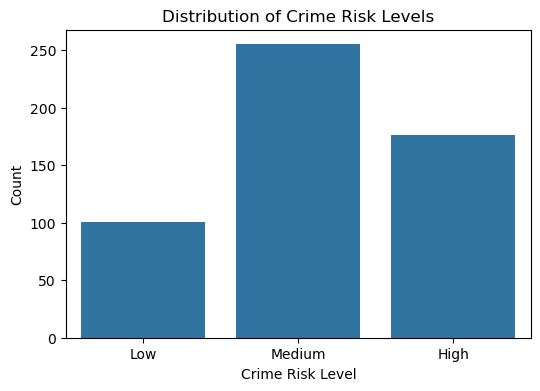

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="Crime_Risk_Level", data=df)
plt.title("Distribution of Crime Risk Levels")
plt.xlabel("Crime Risk Level")
plt.ylabel("Count")
plt.show()


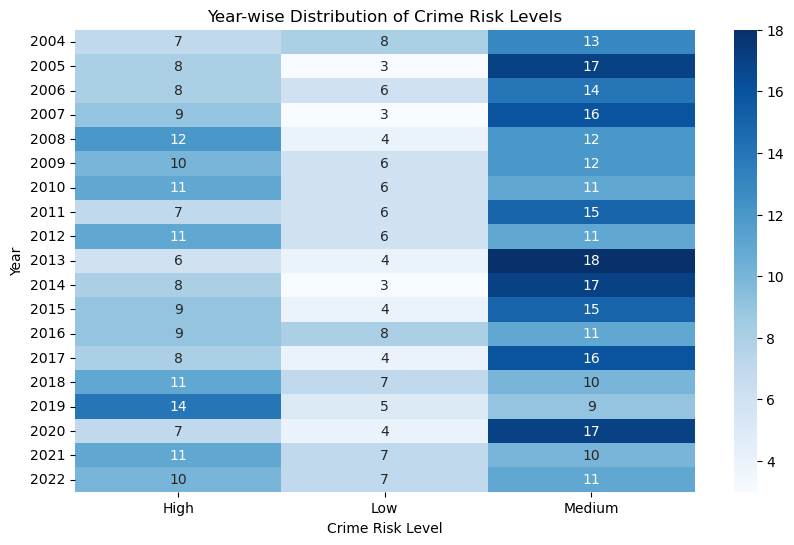

In [5]:
year_risk_heatmap = pd.crosstab(
    df["Year"],
    df["Crime_Risk_Level"]
)

plt.figure(figsize=(10,6))
sns.heatmap(
    year_risk_heatmap,
    annot=True,
    cmap="Blues",
    fmt="d"
)
plt.title("Year-wise Distribution of Crime Risk Levels")
plt.xlabel("Crime Risk Level")
plt.ylabel("Year")
plt.show()





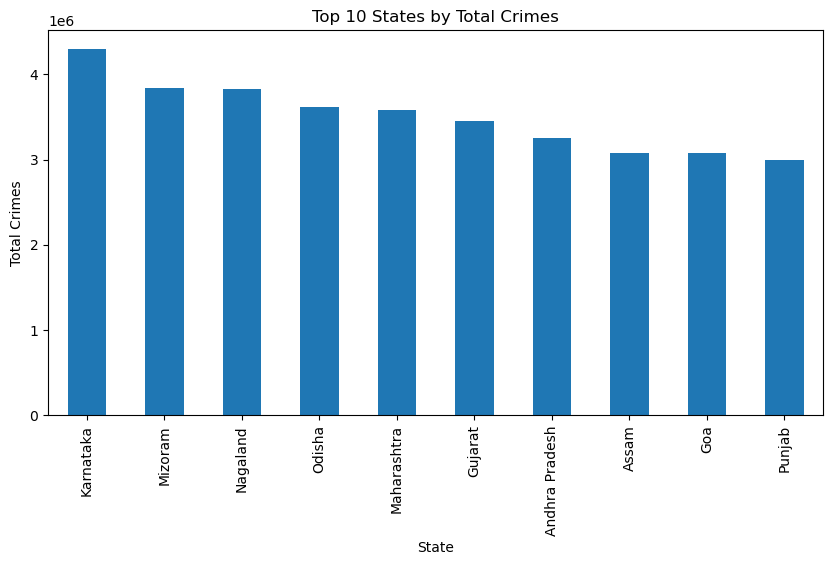

In [6]:
#calculates the total number of crimes for each state using groupby and sum
top_states = (
    df.groupby("State")["Total_Crimes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Total Crimes")
plt.xlabel("State")
plt.ylabel("Total Crimes")
plt.show()


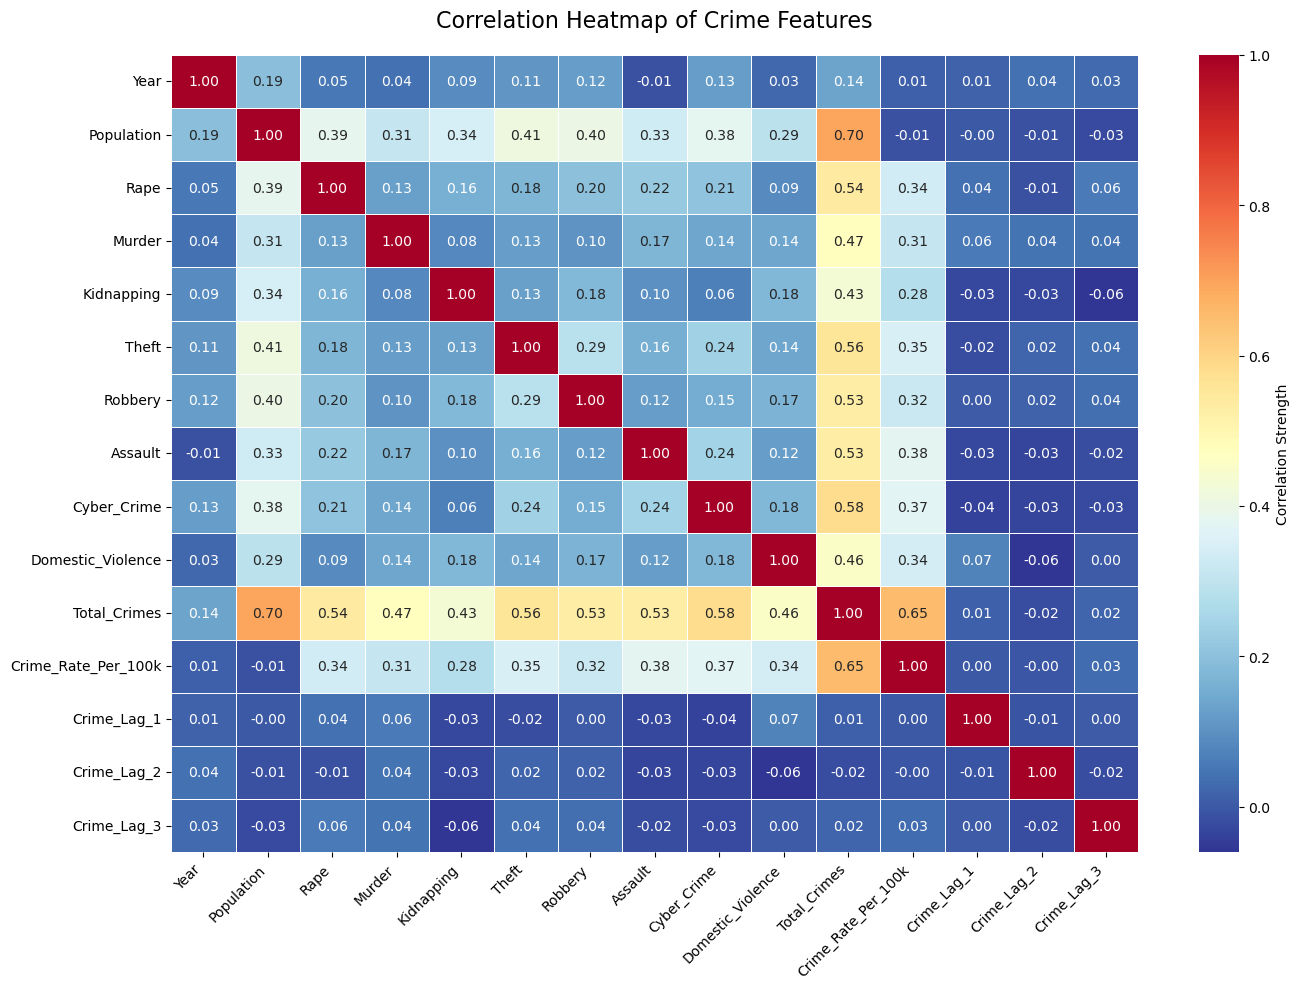

In [7]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,                # Show correlation values
    fmt=".2f",                 # 2 decimal places
    cmap="RdYlBu_r",            # Clear diverging colors
    linewidths=0.5,
    cbar_kws={"label": "Correlation Strength"}
)

plt.title("Correlation Heatmap of Crime Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
#categorical variables converted to numbers
from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
df["State_Encoded"] = le_state.fit_transform(df["State"])

le_target = LabelEncoder()
df["Target"] = le_target.fit_transform(df["Crime_Risk_Level"])


In [30]:
#defines the input features used for training the machine learning model
X = df[[
    "State_Encoded",
    "Year",
    "Crime_Lag_1",
    "Crime_Lag_2",
    "Crime_Lag_3"
]]

y = df["Target"]


In [32]:
from sklearn.model_selection import train_test_split
#splits the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
#imported multiple classification algorithms to compare their performance
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, accuracy_score(y_test, preds))


Logistic 0.4766355140186916
Decision Tree 0.35514018691588783
Random Forest 0.4205607476635514
Gradient Boosting 0.45794392523364486
XGBoost 0.4485981308411215


In [36]:
#Hyperparameter Tuning
#GridSearchCV to find the best parameters for the Random Forest model
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

rf = RandomForestClassifier()
grid = GridSearchCV(rf, param_grid, cv=5)
grid.fit(X_train,y_train)

best_model = grid.best_estimator_


In [13]:
#saved the trained machine learning model and encoders using Joblib
import joblib

joblib.dump(best_model,"crime_future_model.pkl")
joblib.dump(le_state,"state_encoder_A0.pkl")
joblib.dump(le_target,"target_encoder_A0.pkl")


['target_encoder_A0.pkl']